In [1]:
import os
#os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"


#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

os.environ["XLA_FLAGS"] = "--xla_gpu_deterministic_ops=true"

import Analytic_t_dep_sim_mem_saver as ATDS_MS

import jax
jax.config.update("jax_enable_x64", True)
import numpy as np

import matplotlib.pyplot as plt
import jax.numpy as jnp

[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]


In [ ]:
import importlib
importlib.reload(ATDS_MS)


SphHT = True
integrator = 'leapfrog'
plot = False
dt_override = 1
ramp_time = 0

l_band_size = 250
use_multi_gpu = True
sparse_k_batch=16384
r_chunk_size = 1000

compute_dtype = jnp.complex64

L_out_frac = 0.5

Runs = []

for i in range(3):
  print('Run number:', i+1)
  sim = ATDS_MS.StellarSimTDep(m22 = 5, r_half = 0.19, r_half_width = 0.05, no_of_particles = 5, no_time_steps = 1000, total_evolve_time = 10, r_min = 20, 
                                r_max_enclosing_frac = 0.99, no_radius_bins = 1000, SphHT = SphHT, integrator = integrator, 
                                plot = plot, dt_override=dt_override, ramp_time=ramp_time, l_band_size=l_band_size, use_multi_gpu = use_multi_gpu,
                                  sparse_k_batch=sparse_k_batch, r_chunk_size=r_chunk_size, compute_dtype=compute_dtype, L_out_frac=L_out_frac)


  sim.run_simulation()
  Runs.append(sim)

[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
Run number: 1
Loading precomputed R_j_r from /home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses/precomputed_wf/precomputed_R_j_r_m22_5_rbins_1000.npz...
l max from jaxsp: 119
SphHT bandwidth truncated by L_out_frac=0.5: L_max_out = 120 (natural 2L-1 = 239, floor L = 120)
Particle 0: v_circ = 10.559 km/s
Particle 1: v_circ = 10.003 km/s
Particle 2: v_circ = 10.569 km/s
Particle 3: v_circ = 11.277 km/s
Particle 4: v_circ = 10.089 km/s
Mean r: 0.185 kpc
Min T_orb: 104.963 Myr
T_c: 33.972 Myr
dt: 0.034 Gyr
Number of time steps: 294
Ramp phase: 0 steps (0.000 Gyr)
Main phase: 294 steps (9.988 Gyr)
Total: 294 steps
completed rho_lms precomputation
Time step 1 / 294
Building rho_lms for this timestep...
rho_lms built in 6.27 seconds
  Force calls this timestep: 1
Time stepping all particles completed in 7.49 seconds
Time step 2 / 294
Building rho_lms for this timestep...
rho_lms 

In [ ]:
positions_all = []
r_all = []
all_vels_cart = []
kinetic_energy_all = []
potential_energy_all = []
ang_mom_all = []

for sim in Runs:

    positions_all.append(np.array([p.positions_xyz for p in sim.particles]))  # (N_particles, N_steps+1, 3)
    r_all.append(np.array([p.r_values      for p in sim.particles]))  # (N_particles, N_steps+1)
    all_vels_cart.append(np.array([[np.array(v) for v in p.velocities_cart] for p in sim.particles]))
    kinetic_energy_all.append(np.array([p.kinetic_energy for p in sim.particles])) # (N_particles, N_steps+1)
    potential_energy_all.append(np.array([p.potential_energy for p in sim.particles])) # (N_particles, N_steps+1)
    ang_mom_all.append(np.array([p.ang_mom for p in sim.particles])) # (N_particles, N_steps+1, 3)

np.savez('Determinism_Check.npz', positions_all=positions_all, r_all=r_all, all_vels_cart=all_vels_cart, kinetic_energy_all=kinetic_energy_all, potential_energy_all=potential_energy_all, ang_mom_all=ang_mom_all)

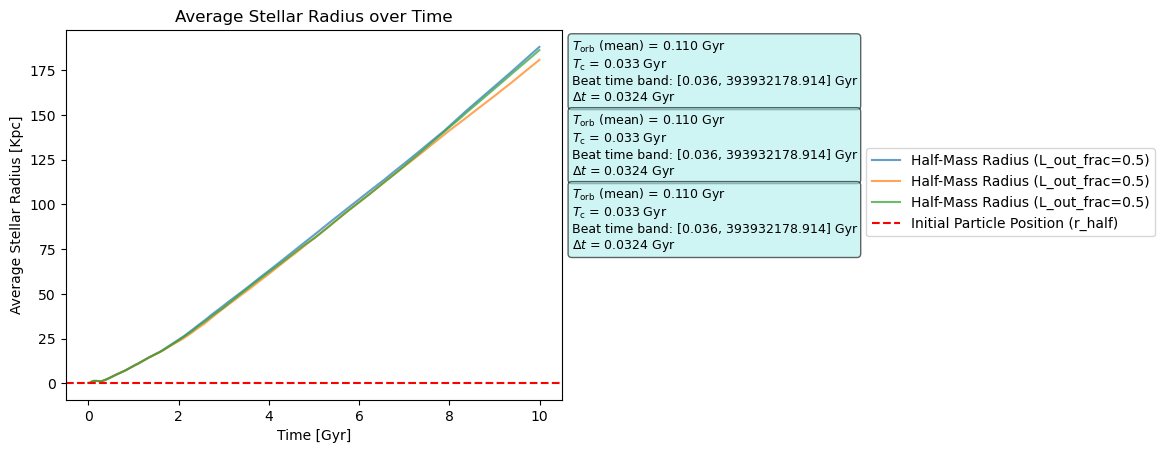

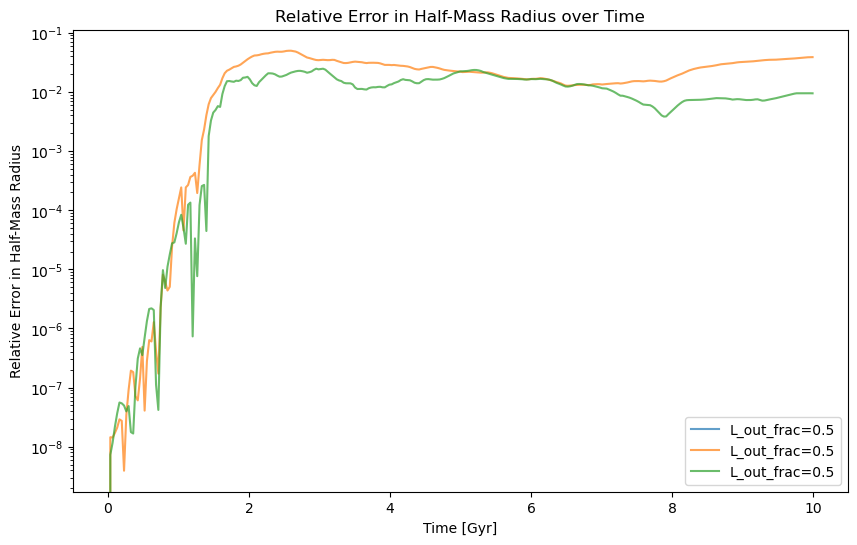

In [ ]:
no_time_steps = Runs[0].no_time_steps


x = np.arange(no_time_steps + 1)  # Time steps array


for i, sim in enumerate(Runs):

    R_half = np.mean(r_all[i], axis=0)  # (N_steps+1,) 

    plt.plot(x * sim.dt * sim.u.to_Gyr, R_half * sim.u.to_Kpc, label=f'Half-Mass Radius (L_out_frac={sim.L_out_frac})', alpha=0.7)
    #for part in range(len(sim.particles)):
    #    plt.plot(x * sim.dt * sim.u.to_Gyr, r_all[i][part] * sim.u.to_Kpc, alpha=0.3, color='gray')
    plt.xlabel('Time [Gyr]')
    plt.ylabel('Average Stellar Radius [Kpc]')
    plt.title('Average Stellar Radius over Time')

    # Timescale diagnostics
    v0 = np.linalg.norm(all_vels_cart[i][:, 0, :], axis=1)
    mean_T_orb = float(np.mean(2 * np.pi * r_all[i][:, 0] / v0) * sim.u.to_Gyr)

    lambda_db_kpc = 19.15 / (sim.m22 * v0 * sim.u.to_kms)
    T_c = lambda_db_kpc / (v0 * sim.u.to_Kpc) * sim.u.to_Gyr

    #plt.axhline(np.mean(lambda_db_kpc), color='g', linestyle='--', label='$\\lambda_{{\\rm db}}$')


    E = np.array(sim.eigen_energies)
    freq_diff = np.abs(E[:, None] - E[None, :])
    T_beat = (2 * np.pi / freq_diff) * sim.u.to_Gyr
    min_T_beat = np.min(T_beat[np.isfinite(T_beat)])
    max_T_beat = np.max(T_beat[np.isfinite(T_beat)])

    dt_Gyr = sim.dt * sim.u.to_Gyr

    info = (
        f"$T_{{\\rm orb}}$ (mean) = {mean_T_orb:.3f} Gyr\n"
        f"$T_{{\\rm c}}$ = {float(np.mean(T_c)):.3f} Gyr\n"
        f"Beat time band: [{min_T_beat:.3f}, {max_T_beat:.3f}] Gyr\n"
        f"$\\Delta t$ = {dt_Gyr:.4f} Gyr"
    )

    plt.text(1.02, 0.98 - i * 0.2, info, transform=plt.gca().transAxes,
            verticalalignment='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='paleturquoise', alpha=0.6))


    
plt.axhline(Runs[0].r_half, color='r', linestyle='--', label='Initial Particle Position (r_half)')
    
plt.legend(bbox_to_anchor=(1.6, 0.7))
#plt.yscale('log')
plt.show()


R_half_truth = np.mean(r_all[0], axis=0)  # L_out_frac = 1
errors = []
for i, sim in enumerate(Runs):
    R_half = np.mean(r_all[i], axis=0)
    error = np.abs(R_half - R_half_truth) / R_half_truth
    errors.append(error)


plt.figure(figsize=(10, 6))
for i, sim in enumerate(Runs):
    plt.plot(x * sim.dt * sim.u.to_Gyr, errors[i], label=f'L_out_frac={sim.L_out_frac}', alpha=0.7)
plt.xlabel('Time [Gyr]')
plt.ylabel('Relative Error in Half-Mass Radius')
plt.title('Relative Error in Half-Mass Radius over Time')
plt.yscale('log')
plt.legend()
plt.show()

In [1]:
import os
#os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"


#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"


import Analytic_t_dep_sim_mem_saver as ATDS_MS

import jax
jax.config.update("jax_enable_x64", True)
import numpy as np

import matplotlib.pyplot as plt
import jax.numpy as jnp

[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]


In [2]:
import importlib
importlib.reload(ATDS_MS)


SphHT = True
integrator = 'leapfrog'
plot = False
dt_override = 1
ramp_time = 0

l_band_size = 250
use_multi_gpu = False
sparse_k_batch=16384
r_chunk_size = 1000

compute_dtype = jnp.complex64

L_out_frac = 0.5

Runs = []

for i in range(3):
  print('Run number:', i+1)
  sim = ATDS_MS.StellarSimTDep(m22 = 5, r_half = 0.19, r_half_width = 0.05, no_of_particles = 5, no_time_steps = 1000, total_evolve_time = 10, r_min = 20, 
                                r_max_enclosing_frac = 0.99, no_radius_bins = 1000, SphHT = SphHT, integrator = integrator, 
                                plot = plot, dt_override=dt_override, ramp_time=ramp_time, l_band_size=l_band_size, use_multi_gpu = use_multi_gpu,
                                  sparse_k_batch=sparse_k_batch, r_chunk_size=r_chunk_size, compute_dtype=compute_dtype, L_out_frac=L_out_frac)


  sim.run_simulation()
  Runs.append(sim)

[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
Run number: 1
Loading precomputed R_j_r from /home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses/precomputed_wf/precomputed_R_j_r_m22_5_rbins_1000.npz...
l max from jaxsp: 119
SphHT bandwidth truncated by L_out_frac=0.5: L_max_out = 120 (natural 2L-1 = 239, floor L = 120)
Particle 0: v_circ = 10.559 km/s
Particle 1: v_circ = 10.003 km/s
Particle 2: v_circ = 10.569 km/s
Particle 3: v_circ = 11.277 km/s
Particle 4: v_circ = 10.089 km/s
Mean r: 0.185 kpc
Min T_orb: 104.963 Myr
T_c: 33.972 Myr
dt: 0.034 Gyr
Number of time steps: 294
Ramp phase: 0 steps (0.000 Gyr)
Main phase: 294 steps (9.988 Gyr)
Total: 294 steps
completed rho_lms precomputation
Time step 1 / 294
Building rho_lms for this timestep...
rho_lms built in 0.01 seconds
  Force calls this timestep: 1
Time stepping all particles completed in 1.02 seconds
Time step 2 / 294
Building rho_lms for this timestep...
rho_lms 

In [5]:
positions_all = []
r_all = []
all_vels_cart = []
kinetic_energy_all = []
potential_energy_all = []
ang_mom_all = []

for sim in Runs:

    positions_all.append(np.array([p.positions_xyz for p in sim.particles]))  # (N_particles, N_steps+1, 3)
    r_all.append(np.array([p.r_values      for p in sim.particles]))  # (N_particles, N_steps+1)
    all_vels_cart.append(np.array([[np.array(v) for v in p.velocities_cart] for p in sim.particles]))
    kinetic_energy_all.append(np.array([p.kinetic_energy for p in sim.particles])) # (N_particles, N_steps+1)
    potential_energy_all.append(np.array([p.potential_energy for p in sim.particles])) # (N_particles, N_steps+1)
    ang_mom_all.append(np.array([p.ang_mom for p in sim.particles])) # (N_particles, N_steps+1, 3)

np.savez('Determinism_Check_Single_GPU.npz', positions_all=positions_all, r_all=r_all, all_vels_cart=all_vels_cart, kinetic_energy_all=kinetic_energy_all, potential_energy_all=potential_energy_all, ang_mom_all=ang_mom_all)

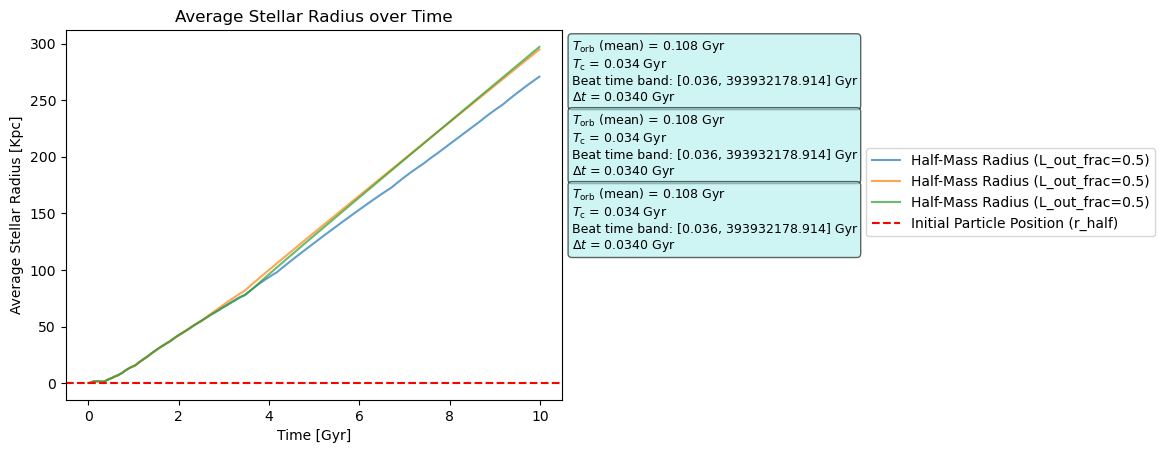

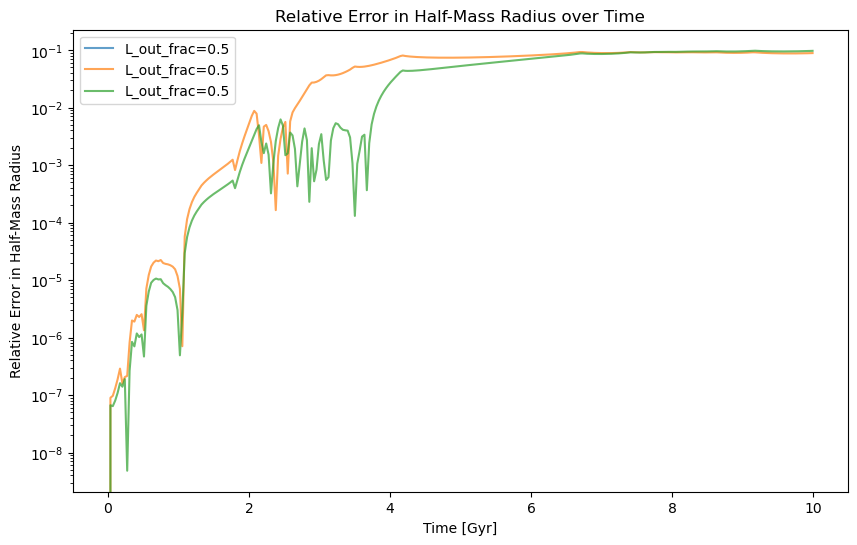

In [6]:
no_time_steps = Runs[0].no_time_steps


x = np.arange(no_time_steps + 1)  # Time steps array


for i, sim in enumerate(Runs):

    R_half = np.mean(r_all[i], axis=0)  # (N_steps+1,) 

    plt.plot(x * sim.dt * sim.u.to_Gyr, R_half * sim.u.to_Kpc, label=f'Half-Mass Radius (L_out_frac={sim.L_out_frac})', alpha=0.7)
    #for part in range(len(sim.particles)):
    #    plt.plot(x * sim.dt * sim.u.to_Gyr, r_all[i][part] * sim.u.to_Kpc, alpha=0.3, color='gray')
    plt.xlabel('Time [Gyr]')
    plt.ylabel('Average Stellar Radius [Kpc]')
    plt.title('Average Stellar Radius over Time')

    # Timescale diagnostics
    v0 = np.linalg.norm(all_vels_cart[i][:, 0, :], axis=1)
    mean_T_orb = float(np.mean(2 * np.pi * r_all[i][:, 0] / v0) * sim.u.to_Gyr)

    lambda_db_kpc = 19.15 / (sim.m22 * v0 * sim.u.to_kms)
    T_c = lambda_db_kpc / (v0 * sim.u.to_Kpc) * sim.u.to_Gyr

    #plt.axhline(np.mean(lambda_db_kpc), color='g', linestyle='--', label='$\\lambda_{{\\rm db}}$')


    E = np.array(sim.eigen_energies)
    freq_diff = np.abs(E[:, None] - E[None, :])
    T_beat = (2 * np.pi / freq_diff) * sim.u.to_Gyr
    min_T_beat = np.min(T_beat[np.isfinite(T_beat)])
    max_T_beat = np.max(T_beat[np.isfinite(T_beat)])

    dt_Gyr = sim.dt * sim.u.to_Gyr

    info = (
        f"$T_{{\\rm orb}}$ (mean) = {mean_T_orb:.3f} Gyr\n"
        f"$T_{{\\rm c}}$ = {float(np.mean(T_c)):.3f} Gyr\n"
        f"Beat time band: [{min_T_beat:.3f}, {max_T_beat:.3f}] Gyr\n"
        f"$\\Delta t$ = {dt_Gyr:.4f} Gyr"
    )

    plt.text(1.02, 0.98 - i * 0.2, info, transform=plt.gca().transAxes,
            verticalalignment='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='paleturquoise', alpha=0.6))


    
plt.axhline(Runs[0].r_half, color='r', linestyle='--', label='Initial Particle Position (r_half)')
    
plt.legend(bbox_to_anchor=(1.6, 0.7))
#plt.yscale('log')
plt.show()


R_half_truth = np.mean(r_all[0], axis=0)  # L_out_frac = 1
errors = []
for i, sim in enumerate(Runs):
    R_half = np.mean(r_all[i], axis=0)
    error = np.abs(R_half - R_half_truth) / R_half_truth
    errors.append(error)


plt.figure(figsize=(10, 6))
for i, sim in enumerate(Runs):
    plt.plot(x * sim.dt * sim.u.to_Gyr, errors[i], label=f'L_out_frac={sim.L_out_frac}', alpha=0.7)
plt.xlabel('Time [Gyr]')
plt.ylabel('Relative Error in Half-Mass Radius')
plt.title('Relative Error in Half-Mass Radius over Time')
plt.yscale('log')
plt.legend()
plt.show()

## After editing Memory_savers 


In [1]:
import os
#os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"


#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"


import Analytic_t_dep_sim_mem_saver as ATDS_MS

import jax
jax.config.update("jax_enable_x64", True)
import numpy as np

import matplotlib.pyplot as plt
import jax.numpy as jnp

[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]


In [2]:
import importlib
importlib.reload(ATDS_MS)


SphHT = True
integrator = 'leapfrog'
plot = False
dt_override = 1
ramp_time = 0

l_band_size = 250
use_multi_gpu = False
sparse_k_batch=16384
r_chunk_size = 1000

compute_dtype = jnp.complex64

L_out_frac = 0.5

Runs = []

for i in range(3):
  print('Run number:', i+1)
  sim = ATDS_MS.StellarSimTDep(m22 = 5, r_half = 0.19, r_half_width = 0.05, no_of_particles = 5, no_time_steps = 1000, total_evolve_time = 10, r_min = 20, 
                                r_max_enclosing_frac = 0.99, no_radius_bins = 1000, SphHT = SphHT, integrator = integrator, 
                                plot = plot, dt_override=dt_override, ramp_time=ramp_time, l_band_size=l_band_size, use_multi_gpu = use_multi_gpu,
                                  sparse_k_batch=sparse_k_batch, r_chunk_size=r_chunk_size, compute_dtype=compute_dtype, L_out_frac=L_out_frac)


  sim.run_simulation()
  Runs.append(sim)

[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
Run number: 1
Loading precomputed R_j_r from /home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses/precomputed_wf/precomputed_R_j_r_m22_5_rbins_1000.npz...
l max from jaxsp: 119
SphHT bandwidth truncated by L_out_frac=0.5: L_max_out = 120 (natural 2L-1 = 239, floor L = 120)
Particle 0: v_circ = 10.559 km/s
Particle 1: v_circ = 10.003 km/s
Particle 2: v_circ = 10.569 km/s
Particle 3: v_circ = 11.277 km/s
Particle 4: v_circ = 10.089 km/s
Mean r: 0.185 kpc
Min T_orb: 104.963 Myr
T_c: 33.972 Myr
dt: 0.034 Gyr
Number of time steps: 294
Ramp phase: 0 steps (0.000 Gyr)
Main phase: 294 steps (9.988 Gyr)
Total: 294 steps
completed rho_lms precomputation


E0625 07:17:43.752481 3570505 slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %sort.17 = (s32[579891]{0}, s64[579891]{0}, s32[579891]{0}) sort(%constant.2685, %iota.72, %iota.94), dimensions={0}, is_stable=true, to_apply=%region_0.6.clone, metadata={op_name="jit(calc_rho_lm_at_parts_and_call_insert)/jit(compute_rho_lm_at_particles_sphht_jit)/jit(argsort)/sort" stack_frame_id=94}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
E0625 07:17:49.836363 2863023 slow_operation_alarm.cc:140] The operation took 7.084676768s
Constant folding an instruction is taking > 1s:

  %sort.17 = (s32[579891]{0}, s64[579891]{0}, 

Time step 1 / 294
Building rho_lms for this timestep...
rho_lms built in 0.01 seconds
  Force calls this timestep: 1
Time stepping all particles completed in 1.01 seconds
Time step 2 / 294
Building rho_lms for this timestep...
rho_lms built in 0.00 seconds
  Force calls this timestep: 1
Time stepping all particles completed in 1.00 seconds
Time step 3 / 294
Building rho_lms for this timestep...
rho_lms built in 0.00 seconds
  Force calls this timestep: 1
Time stepping all particles completed in 1.00 seconds
Time step 4 / 294
Building rho_lms for this timestep...
rho_lms built in 0.00 seconds
  Force calls this timestep: 1
Time stepping all particles completed in 1.00 seconds
Time step 5 / 294
Building rho_lms for this timestep...
rho_lms built in 0.01 seconds
  Force calls this timestep: 1
Time stepping all particles completed in 0.99 seconds
Time step 6 / 294
Building rho_lms for this timestep...
rho_lms built in 0.00 seconds
  Force calls this timestep: 1
Time stepping all particles 

E0625 07:29:49.616516 3570505 slow_operation_alarm.cc:73] Constant folding an instruction is taking > 2s:

  %sort.17 = (s32[579891]{0}, s64[579891]{0}, s32[579891]{0}) sort(%constant.2685, %iota.72, %iota.94), dimensions={0}, is_stable=true, to_apply=%region_0.6.clone, metadata={op_name="jit(calc_rho_lm_at_parts_and_call_insert)/jit(compute_rho_lm_at_particles_sphht_jit)/jit(argsort)/sort" stack_frame_id=94}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
E0625 07:29:54.956135 2863023 slow_operation_alarm.cc:140] The operation took 7.339924989s
Constant folding an instruction is taking > 2s:

  %sort.17 = (s32[579891]{0}, s64[579891]{0}, 

Time step 1 / 294
Building rho_lms for this timestep...
rho_lms built in 0.01 seconds
  Force calls this timestep: 1
Time stepping all particles completed in 1.01 seconds
Time step 2 / 294
Building rho_lms for this timestep...
rho_lms built in 0.00 seconds
  Force calls this timestep: 1
Time stepping all particles completed in 1.00 seconds
Time step 3 / 294
Building rho_lms for this timestep...
rho_lms built in 0.00 seconds
  Force calls this timestep: 1
Time stepping all particles completed in 1.00 seconds
Time step 4 / 294
Building rho_lms for this timestep...
rho_lms built in 0.00 seconds
  Force calls this timestep: 1
Time stepping all particles completed in 0.99 seconds
Time step 5 / 294
Building rho_lms for this timestep...
rho_lms built in 0.01 seconds
  Force calls this timestep: 1
Time stepping all particles completed in 1.00 seconds
Time step 6 / 294
Building rho_lms for this timestep...
rho_lms built in 0.00 seconds
  Force calls this timestep: 1
Time stepping all particles 

E0625 07:35:31.455541 3570505 slow_operation_alarm.cc:73] Constant folding an instruction is taking > 4s:

  %sort.17 = (s32[579891]{0}, s64[579891]{0}, s32[579891]{0}) sort(%constant.2685, %iota.72, %iota.94), dimensions={0}, is_stable=true, to_apply=%region_0.6.clone, metadata={op_name="jit(calc_rho_lm_at_parts_and_call_insert)/jit(compute_rho_lm_at_particles_sphht_jit)/jit(argsort)/sort" stack_frame_id=94}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
E0625 07:35:34.585175 2863023 slow_operation_alarm.cc:140] The operation took 7.130476017s
Constant folding an instruction is taking > 4s:

  %sort.17 = (s32[579891]{0}, s64[579891]{0}, 

Time step 1 / 294
Building rho_lms for this timestep...
rho_lms built in 0.01 seconds
  Force calls this timestep: 1
Time stepping all particles completed in 1.00 seconds
Time step 2 / 294
Building rho_lms for this timestep...
rho_lms built in 0.00 seconds
  Force calls this timestep: 1
Time stepping all particles completed in 0.99 seconds
Time step 3 / 294
Building rho_lms for this timestep...
rho_lms built in 0.01 seconds
  Force calls this timestep: 1
Time stepping all particles completed in 0.99 seconds
Time step 4 / 294
Building rho_lms for this timestep...
rho_lms built in 0.00 seconds
  Force calls this timestep: 1
Time stepping all particles completed in 0.99 seconds
Time step 5 / 294
Building rho_lms for this timestep...
rho_lms built in 0.01 seconds
  Force calls this timestep: 1
Time stepping all particles completed in 1.00 seconds
Time step 6 / 294
Building rho_lms for this timestep...
rho_lms built in 0.00 seconds
  Force calls this timestep: 1
Time stepping all particles 

In [ ]:
positions_all = []
r_all = []
all_vels_cart = []
kinetic_energy_all = []
potential_energy_all = []
ang_mom_all = []

for sim in Runs:

    positions_all.append(np.array([p.positions_xyz for p in sim.particles]))  # (N_particles, N_steps+1, 3)
    r_all.append(np.array([p.r_values      for p in sim.particles]))  # (N_particles, N_steps+1)
    all_vels_cart.append(np.array([[np.array(v) for v in p.velocities_cart] for p in sim.particles]))
    kinetic_energy_all.append(np.array([p.kinetic_energy for p in sim.particles])) # (N_particles, N_steps+1)
    potential_energy_all.append(np.array([p.potential_energy for p in sim.particles])) # (N_particles, N_steps+1)
    ang_mom_all.append(np.array([p.ang_mom for p in sim.particles])) # (N_particles, N_steps+1, 3)

np.savez('Determinism_Check_Single_GPU.npz', positions_all=positions_all, r_all=r_all, all_vels_cart=all_vels_cart, kinetic_energy_all=kinetic_energy_all, potential_energy_all=potential_energy_all, ang_mom_all=ang_mom_all)

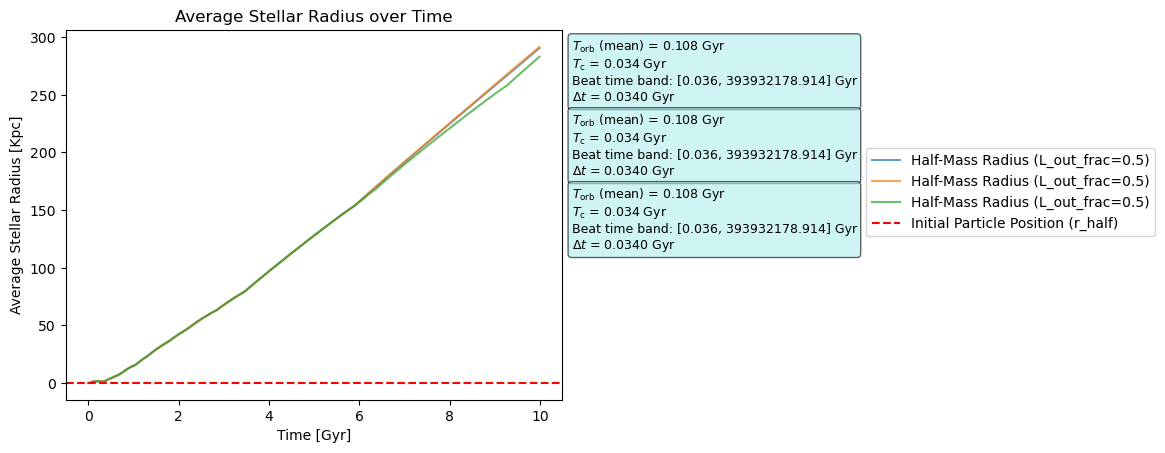

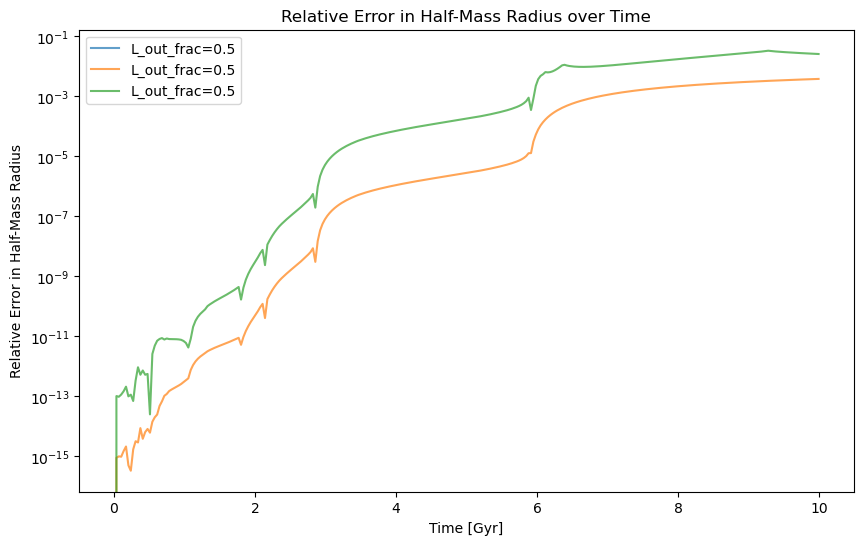

In [4]:
no_time_steps = Runs[0].no_time_steps


x = np.arange(no_time_steps + 1)  # Time steps array


for i, sim in enumerate(Runs):

    R_half = np.mean(r_all[i], axis=0)  # (N_steps+1,) 

    plt.plot(x * sim.dt * sim.u.to_Gyr, R_half * sim.u.to_Kpc, label=f'Half-Mass Radius (L_out_frac={sim.L_out_frac})', alpha=0.7)
    #for part in range(len(sim.particles)):
    #    plt.plot(x * sim.dt * sim.u.to_Gyr, r_all[i][part] * sim.u.to_Kpc, alpha=0.3, color='gray')
    plt.xlabel('Time [Gyr]')
    plt.ylabel('Average Stellar Radius [Kpc]')
    plt.title('Average Stellar Radius over Time')

    # Timescale diagnostics
    v0 = np.linalg.norm(all_vels_cart[i][:, 0, :], axis=1)
    mean_T_orb = float(np.mean(2 * np.pi * r_all[i][:, 0] / v0) * sim.u.to_Gyr)

    lambda_db_kpc = 19.15 / (sim.m22 * v0 * sim.u.to_kms)
    T_c = lambda_db_kpc / (v0 * sim.u.to_Kpc) * sim.u.to_Gyr

    #plt.axhline(np.mean(lambda_db_kpc), color='g', linestyle='--', label='$\\lambda_{{\\rm db}}$')


    E = np.array(sim.eigen_energies)
    freq_diff = np.abs(E[:, None] - E[None, :])
    T_beat = (2 * np.pi / freq_diff) * sim.u.to_Gyr
    min_T_beat = np.min(T_beat[np.isfinite(T_beat)])
    max_T_beat = np.max(T_beat[np.isfinite(T_beat)])

    dt_Gyr = sim.dt * sim.u.to_Gyr

    info = (
        f"$T_{{\\rm orb}}$ (mean) = {mean_T_orb:.3f} Gyr\n"
        f"$T_{{\\rm c}}$ = {float(np.mean(T_c)):.3f} Gyr\n"
        f"Beat time band: [{min_T_beat:.3f}, {max_T_beat:.3f}] Gyr\n"
        f"$\\Delta t$ = {dt_Gyr:.4f} Gyr"
    )

    plt.text(1.02, 0.98 - i * 0.2, info, transform=plt.gca().transAxes,
            verticalalignment='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='paleturquoise', alpha=0.6))


    
plt.axhline(Runs[0].r_half, color='r', linestyle='--', label='Initial Particle Position (r_half)')
    
plt.legend(bbox_to_anchor=(1.6, 0.7))
#plt.yscale('log')
plt.show()


R_half_truth = np.mean(r_all[0], axis=0)  # L_out_frac = 1
errors = []
for i, sim in enumerate(Runs):
    R_half = np.mean(r_all[i], axis=0)
    error = np.abs(R_half - R_half_truth) / R_half_truth
    errors.append(error)


plt.figure(figsize=(10, 6))
for i, sim in enumerate(Runs):
    plt.plot(x * sim.dt * sim.u.to_Gyr, errors[i], label=f'L_out_frac={sim.L_out_frac}', alpha=0.7)
plt.xlabel('Time [Gyr]')
plt.ylabel('Relative Error in Half-Mass Radius')
plt.title('Relative Error in Half-Mass Radius over Time')
plt.yscale('log')
plt.legend()
plt.show()

## Still not deterministic as lots of GPU sums throughout code but slightly better and much faster so keeping change